<a href="https://colab.research.google.com/drive/1_7ZERbrfywPfYD4pPOh6PNoDqQ-0Yq8D?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

# setting the seed
rng.current = 1
samples = [rng() for _ in range(1000)]


### Problem 1
Implement serial test and apply to a `samples`

In [4]:
k = 10
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


lst = [samples[i:i+2] for i in range(0, len(samples)-1, 2)]

x = [pair[0] for pair in lst]
y = [pair[1] for pair in lst]

f_obs = np.histogram2d(x, y, bins = k, range = [[0,1], [0,1]])[0]
f_exp = np.full(k*k, len(lst) / (k*k)).reshape(k, k)

f_obs_flat = f_obs.flatten()
f_exp_flat = f_exp.flatten()

f_obs_flat, f_exp_flat, stats.chisquare(f_obs_flat, f_exp_flat)








(array([ 6., 12.,  5.,  2.,  2.,  3.,  4.,  7.,  3.,  3.,  6.,  4.,  5.,
         1., 10.,  8.,  5.,  4.,  6.,  3.,  4.,  6.,  4.,  8.,  5.,  5.,
         2.,  4.,  3.,  2.,  3.,  5.,  5.,  3.,  8.,  5.,  5.,  8.,  5.,
        13.,  7.,  4.,  4.,  5.,  3.,  3.,  4.,  7.,  3.,  0.,  3.,  6.,
         0.,  4.,  5.,  6.,  4.,  6.,  5.,  6.,  2.,  6.,  3.,  3.,  8.,
         5.,  3.,  4.,  9.,  0.,  2.,  7.,  9.,  7.,  8.,  6.,  5.,  4.,
         7.,  1.,  7.,  5.,  2.,  6.,  4.,  5.,  6.,  9.,  7.,  5.,  3.,
         7.,  7.,  5.,  7.,  7.,  3.,  3.,  7.,  9.]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.

### Problem 2*
Implement permutation test and apply to a `samples`

In [5]:
def chunked(lst, n):
    return [lst[i:i + n] for i in range(0, len(lst), n)]

print(chunked([1, 2, 3, 4, 5, 6, 7, 8], 3))
# Вывод: [[1, 2, 3], [4, 5, 6], [7, 8]]


[[1, 2, 3], [4, 5, 6], [7, 8]]


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [6]:
import plotly.express as px

def rng_bad(m = 2 ** 31, a = 65539, c = 0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def rng_good(m = 2 ** 31-1, a = 16807, c = 0):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m


rng_bad.current = 1
rng_good.current = 1


samples_good = [rng_good() for _ in range(30000)]
samples_bad = [rng_bad() for _ in range(30000)]



def chi_square3d(samp, k):
  gav = [samp[i:i+3] for i in range(0, len(samp)-1, 3)]
  gav = np.array(gav)

  f_obs = np.histogramdd(gav, bins = k, range = [[0,1], [0,1], [0,1]])[0]
  f_exp = np.full(k*k*k, len(gav) / (k*k*k)).reshape(k, k, k)
  f_obs_flat = f_obs.flatten()
  f_exp_flat = f_exp.flatten()
  chi2, p = stats.chisquare(f_obs_flat, f_exp_flat)
  return chi2, p

chi_g, p_g = chi_square3d(samples_good, 10)
chi_b, p_b = chi_square3d(samples_bad, 10)

print(f"rng_good: chi2={chi_g:.2f}, p-value={p_g:.4f} -> {'test passed' if p_g > 0.05 else 'test failed'}")
print(f"rng_bad:  chi2={chi_b:.2f}, p-value={p_b:.4f} -> {'test passed' if p_b > 0.05 else 'test failed'}")



def plane_ks_test(samples):
    t = np.array([samples[i:i+3] for i in range(len(samples)-2)])
    r = np.mod(t[:, 2] - 6*t[:, 1] + 9*t[:, 0], 1.0)
    ks = stats.kstest(r, 'uniform')
    return r, ks

r_good, ks_good = plane_ks_test(samples_good)
r_bad, ks_bad = plane_ks_test(samples_bad)

print("rng_good:", ks_good)
print("rng_bad :", ks_bad)


print("Колмогоров убил плохой тест")



rng_good: chi2=999.80, p-value=0.4869 -> test passed
rng_bad:  chi2=1031.20, p-value=0.2334 -> test passed
rng_good: KstestResult(statistic=np.float64(0.0033125855439190555), pvalue=np.float64(0.8959115887513035), statistic_location=np.float64(0.41177314958152156), statistic_sign=np.int8(-1))
rng_bad : KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(0.0), statistic_sign=np.int8(1))
Колмогоров убил плохой тест


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

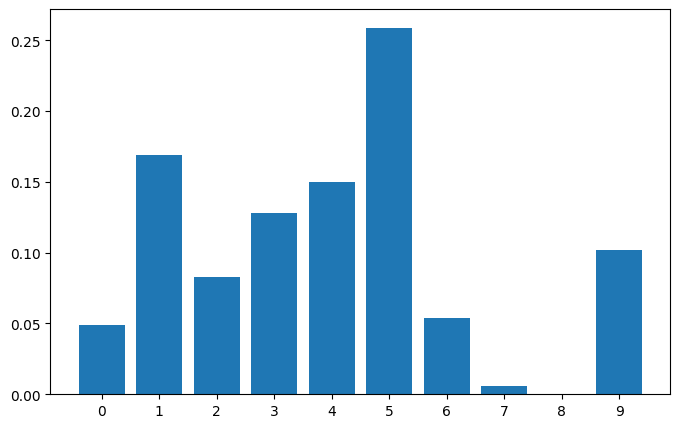

In [7]:
def rng_good(m = 2 ** 31-1, a = 16807, c = 0):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m

rng_good.current = 1

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
numb = np.arange(10)
probab = np.array(weights / weights.sum())

pairs = np.column_stack((numb, probab))
np.set_printoptions(suppress=True, precision=7)

sorted_pairs = np.array(sorted(pairs, key = lambda x: x[1]))
sorted_pairs = sorted_pairs[::-1]

sorted_prob = sorted_pairs[:, 1]
sorted_numb = sorted_pairs[:, 0]

summ = np.cumsum(sorted_prob)

meow = [rng_good() for _ in range(1000)]
sample = []

for k in range(len(meow)):
  if (meow[k] < summ[0] and meow[k] >= 0):
    sample.append(sorted_numb[0])


  for i in range(1, 10):
    if (meow[k] >= summ[i-1] and meow[k] < summ[i]):
      sample.append(sorted_numb[i])
      break
plt.figure(figsize=(8, 5))
plt.hist(sample, bins=np.arange(-0.5, 10.5, 1), density=True, rwidth=0.8)
plt.xticks(range(10))

plt.show()


### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

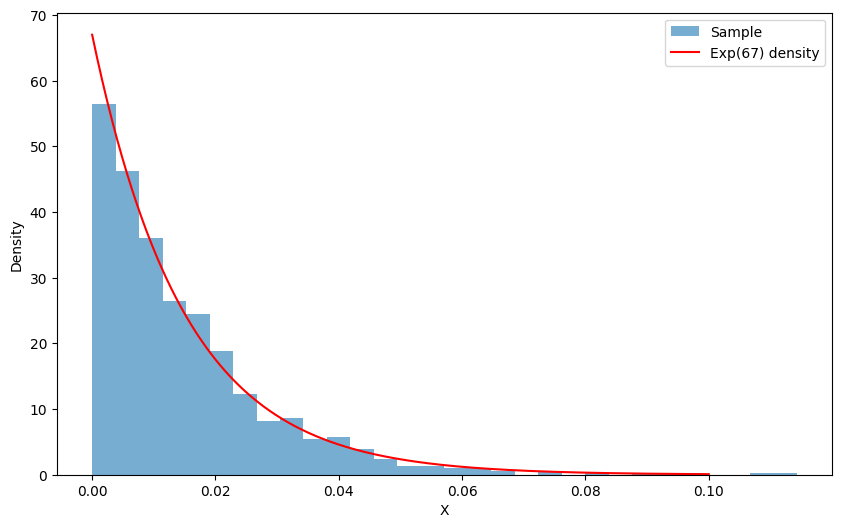

In [8]:
lam = 67
U = np.random.rand(1000)
X = -np.log(1-U)/67
plt.figure(figsize = (10, 6))
plt.hist(X, bins=30, density = True, alpha=0.6, label='Sample')
x_vals = np.linspace(0, 0.1, 500)
Y = 67 * np.exp(-67*x_vals)


plt.plot(x_vals, Y, color = "red", label = "Exp(67) density")
plt.xlabel('X')
plt.ylabel('Density')

plt.legend()
plt.show()


### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

<Figure size 640x480 with 0 Axes>

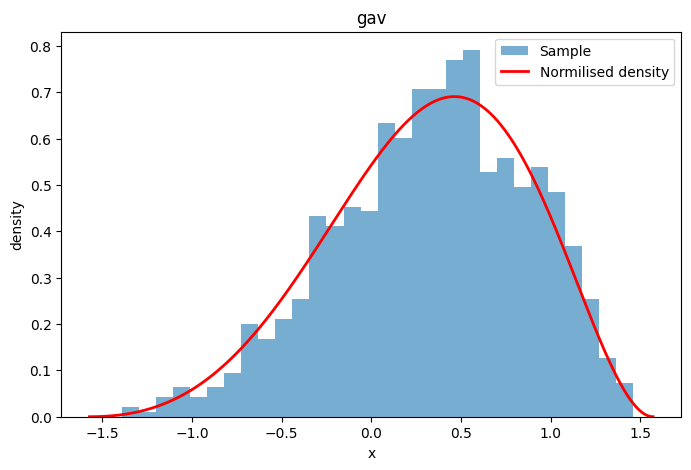

In [10]:
from scipy import stats
fig = plt.figure()
x = np.linspace(-np.pi/2, np.pi/2, 1000)

def f(x):
    return np.exp(x) * np.cos(x)**2
a, b = -np.pi/2, np.pi/2
x_dens = np.linspace(a + 1e-6, b - 1e-6, 10000)
M = np.max(f(x_dens))
samples = []
while len(samples) < 1000:
    x = np.random.uniform(a, b)
    y = np.random.uniform(0, M)
    if y <= f(x):
        samples.append(x)

samples = np.array(samples)
Z = np.trapezoid(f(x_dens), x_dens)
pdf_true = f(x_dens) / Z
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Sample')
plt.plot(x_dens, pdf_true, 'r-', lw=2, label='Normilised density')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.title('gav')
plt.show()


### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

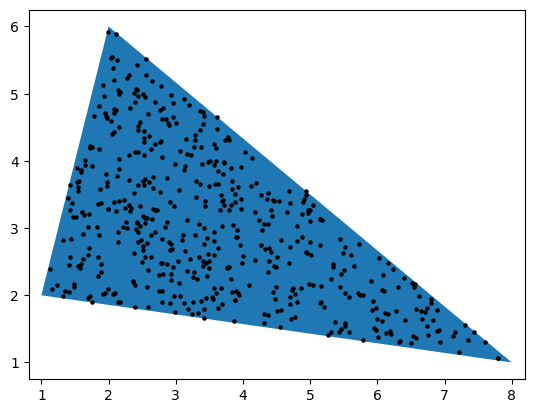

In [11]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1 ,2])
B = np.array([2, 6])
C = np.array([8, 1])


u = np.random.rand(500)
v = np.random.rand(500)
P = []
for i in range(500):

  if (u[i] + v[i] > 1):
    u[i] = 1 - u[i]
    v[i] = 1 - v[i]
  P.append(A + u[i]*(B - A) + v[i]*(C - A))




P = np.array(P)



fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.scatter(P[:, 0], P[:, 1], color = "black", s = 5)
plt.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

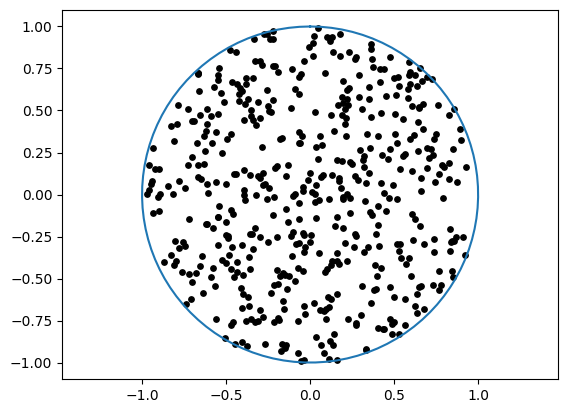

In [13]:
fig = plt.figure()
angles = np.random.uniform(0, 2*np.pi, 500)
r = np.sqrt(np.random.uniform(0, 1, 500))

x = r * np.cos(angles)
y = r * np.sin(angles)

plt.scatter(x,y, color = "black", s = 15)






t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [17]:
import seaborn as sns

Sample mean:
[4.0067225 6.969872 ]

Exact mean:
[4 7]

Sample covariance:
[[19.9922759 -3.8249716]
 [-3.8249716 41.7204691]]

Exact covariance:
[[20 -4]
 [-4 40]]


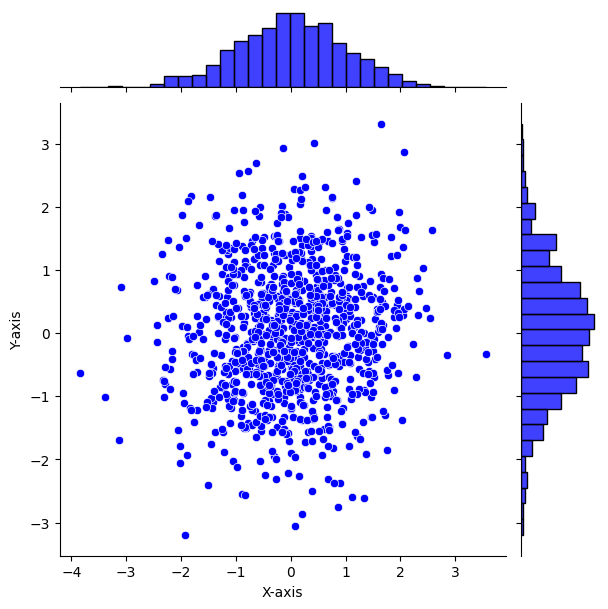

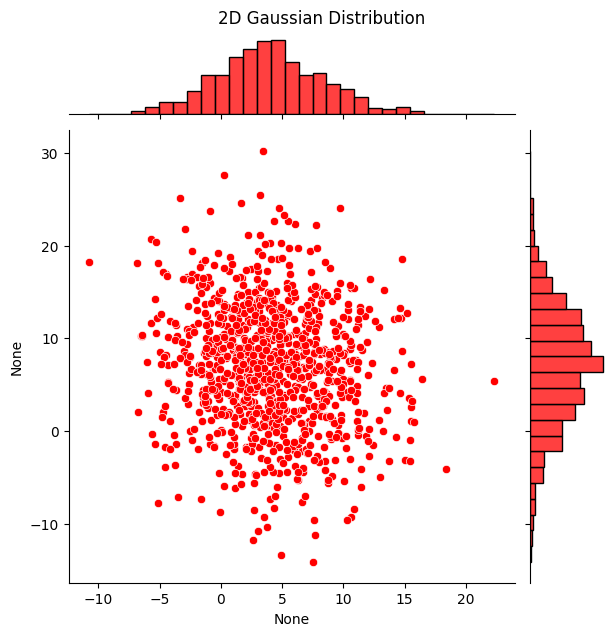

In [43]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


ul = []
vl = []

z = np.empty((n, 2))
k = 0

while k < n:
  u = np.random.uniform(-1, 1)
  v = np.random.uniform(-1, 1)
  s = u**2 + v**2
  if ((s < 1) and (s > 0)):
    factor = np.sqrt(-2*np.log(s)/s)
    z[k, 0] = u * factor
    z[k, 1] = v * factor
    k += 1



z1 = 4 + np.sqrt(20)*z[:, 0]
z2 = 7 - (4 / np.sqrt(20)) * z[:, 0] + np.sqrt(40 - 16/20) * z[:, 1]
Z = np.column_stack((z1, z2))



sample_mean = Z.mean(axis = 0)
sample_cov = np.cov(Z, rowvar = False)

print("Sample mean:")
print(sample_mean)
print("\nExact mean:")
print(np.array([4, 7]))

print("\nSample covariance:")
print(sample_cov)
print("\nExact covariance:")
print(np.array([[20, -4],
                [-4, 40]]))





joint_plot = sns.jointplot(x=x, y=y, color="blue")
sns.jointplot(x=Z[:, 0], y=Z[:, 1], color = "red")
joint_plot.set_axis_labels('X-axis', 'Y-axis')



plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()